# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Farhan Nawwafal Pramudia
- **Email:** farhan091204@gmail.com
- **ID Dicoding:** CDCC237D6Y2155

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apa saja top 3 teratas produk yang paling banyak dibeli ?
- **Pertanyaan 2:** Apa saja top 3 terbawah produk yang paling banyak dibeli ?
- **Pertanyaan 3:** Payment_Type apa yang paling banyak digunakan untuk pembayaran dan berapa persentasenya ?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df customers_dataset

In [2]:
customer_df = pd.read_csv('./data/customers_dataset.csv')
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Load df products_dataset

In [3]:
product_df = pd.read_csv('./data/products_dataset.csv')
product_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Load df product_category_name_translation

In [4]:
product_category_df = pd.read_csv('./data/product_category_name_translation.csv')
product_category_df.head(
    
)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


#### Load df orders_dataset

In [5]:
order_df = pd.read_csv('./data/orders_dataset.csv')
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load df order_items_dataset

In [6]:
order_item_df = pd.read_csv('./data/order_items_dataset.csv')
order_item_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load df order_payments_dataset

In [7]:
order_payment_df = pd.read_csv('./data/order_payments_dataset.csv')
order_payment_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Load df order_reviews_dataset

In [8]:
order_review_df = pd.read_csv('./data/order_reviews_dataset.csv')
order_review_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#### Load df sellers_dataset

In [9]:
seller_df = pd.read_csv('./data/sellers_dataset.csv')
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


#### Load df geolocation_dataset

In [10]:
geolocation_df = pd.read_csv('./data/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


### Assessing Data

#### Identifying customer_df problem

In [11]:
# Mengecek struktur data dari customer_df
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Jumlah baris data di setiap kolom, sama. Artinya tidak ada indikasi missing value
- Tipe data dari etiap fitur juga sudah sesuai. Jadi tidak ada action yang dilakukan 

In [12]:
# Melihat statistik data
customer_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada kolom baris top dan kolom customer_city, terdapat nilai sao paulo. Artinya, cukup banyak customer yang berasal dari kota sao paulo
- Meski banyak data NaN, pada dasarnya fungsi describe ini akan melihat statistik data numerik 
- Jadi data NaN di sini tidak perlu dihapus, karena itu adalah data kategorikal

In [13]:
# Cek missing value
customer_df.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Terbukti bahwa tidak ada missing value di setiap kolomnya

In [14]:
# Cek duplikasi data
print(f'Jumlah duplikasi data customer_df: {customer_df.duplicated().sum()}')

Jumlah duplikasi data customer_df: 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak adanya indikasi data duplikat. Artinya data customer_df sudah bersih

#### Identifying product_df problem

In [15]:
# Mengecek struktur data dari product_df
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Steps to Take:**
- Menangani missing value pada tahap cleaning data untuk product_df

**Insight:** (Opsional)
- Terdapat perbedaan jumlah baris data di setiap kolom. Artinya ada indikasi missing value di beberapa kolom

In [16]:
# Melihat statistik data
product_df.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada kolom baris top dan kolom product_category_name, terdapat nilai cama_mesa_banho. Artinya, kategori produk yang paling banyak adalah cama_mesa_banho
- Meski banyak data NaN, pada dasarnya fungsi describe ini akan melihat statistik data numerik
- Jadi data NaN di sini tidak perlu dihapus, karena itu adalah data kategorikal

In [17]:
# Cek missing value
product_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

**Steps to Take:**
- Menangani missing value pada tahap cleaning data

**Insight:** (Opsional)
- Terbukti bahwa ada missing value di setiap kolomnya. Hal ini dihandle di proses cleaning data

In [18]:
# Cek duplikasi data
print(f'Jumlah duplikasi data customer_df: {product_df.duplicated().sum()}')

Jumlah duplikasi data customer_df: 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak adanya indikasi data duplikat. Artinya data product_df sudah bersih

#### Identifying product_category_df

In [19]:
# Mengecek struktur data dari product_category_df
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Jumlah baris antar fiturnya sama. Artinya data ini tidak memiliki missing value

In [20]:
# Melihat statistik data
product_category_df.describe(include='all')

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada hasil di atas, dapat terlihat bahwa product kategori yang paling banyak jumlahnya, adalah health_beauty

In [21]:
# Cek missing value
product_category_df.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Terbukti bahwa tidak ada missing value di setiap kolomnya

In [22]:
# Cek duplikasi data
print(f'Jumlah duplikasi data product_category_df: {product_category_df.duplicated().sum()}')

Jumlah duplikasi data product_category_df: 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Data product_category_df tidak memiliki duplikasi data
- Secara keseluruhan, data ini bersih. Sehingga tidak ada yang perlu dilakukan pada tahap cleaning data

#### Identifying order_df problem

In [23]:
# Mengecek struktur data dari order_df
order_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Steps to Take:**
- Menangani masalah missing value pada proses cleaning data
- Mengubah tipe data object menjadi datetime, pada kolom order_purchase_timestamp hingga kolom order_estimated_delivery_date

**Insight:** (Opsional)
- Terdapat perbedaan jumlah baris data di setiap kolom. Artinya ada indikasi missing value di beberapa kolom
- Pada kolom order_purchase_timestamp sampai ke kolom order_estimated_delivery_date, semua tipe datanya adalah object. Seharusnya ini datetime

In [24]:
# Melihat statistik data
order_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada kolom baris top dan kolom order status, terdapat nilai delivered. Artinya, status order nya kebanyakan sudah terkirim

In [25]:
# Cek missing value
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**Steps to Take:**
- Menangani missing value pada tahap cleaning data

**Insight:** (Opsional)
- Terbukti bahwa ada missing value di setiap kolomnya. Hal ini dihandle di proses cleaning data

In [26]:
# Cek duplikasi data
print(f'Jumlah duplikasi data order_df  : {order_df.duplicated().sum()}')

Jumlah duplikasi data order_df  : 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak ada indikasi bahwa data ini memiliki data duplikat

#### Identifying order_item_df

In [27]:
# Mengecek struktur data dari order_item_df
order_item_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Steps to Take:**
- Mengubah tipe data object menjadi datetime, pada kolom shipping_limit_date

**Insight:** (Opsional)
- Jumlah baris setiap kolom, sama. Artinya tidak ada indikasi missing value
- Pada kolom shipping_limit_date tipe datanya adalah object. Seharusnya ini datetime

In [28]:
# Melihat statistik data
order_item_df.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak ada

In [29]:
# Cek missing value
order_item_df.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

**Steps to Take:**
- TIdak ada

**Insight:** (Opsional)
- Terbukti bahwa di setiap kolom, tidak memiliki missing value

In [30]:
# Cek duplikasi data
print(f'Jumlah duplikasi data order_item_df  : {order_item_df.duplicated().sum()}')

Jumlah duplikasi data order_item_df  : 0


**Steps to Take:**
- TIdak ada

**Insight:** (Opsional)
- Data order_item ini tidak memiliki order yang duplikat

#### Identifying order_payment_df

In [31]:
# Mengecek struktur data dari order_payment_df
order_payment_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Jumlah baris setiap kolom, sama. Artinya tidak ada indikasi missing value
- Setiap kolom juga tipe datanya sudah benar. Artinya tidak ada indikasi masalah di sini

In [32]:
# Melihat statistik data
order_payment_df.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada baris top kolom payment_type, terdapat nilai credit_card. Artinya banyak customer yang melakukan pembayaran orderannya itu menggunakan credit card

In [33]:
# Cek missing value
order_payment_df.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Terbukti bahwa tidak ada indikasi missing value

In [34]:
# Cek duplikasi data
print(f'Jumlah duplikasi data order_payment_df  : {order_payment_df.duplicated().sum()}')

Jumlah duplikasi data order_payment_df  : 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Data ini tidak memiliki duplikasi data
- Secara keseluruhan, data ini sudah bersih. Tidak perlu dilakukan cleaning data

#### Identifying order_review_df

In [35]:
# Mengecek struktur data dari order_review_df
order_review_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Steps to Take:**
- Handle missing value pada kolom review_comment_title dan review_comment_message
- Mengubah tipe data object menjadi datetime pada kolom review_creation_date dan review_answer_timestamp

**Insight:** (Opsional)
- Pada kolom review_comment_title dan review_comment_message, terdapat jumlah baris yang berbeda
- Hal itu mendandakan missing value. Ini disebabkan karena customer tidak mengisi data komen dari judul dan isinya. Hal ini akan ditangani pada proses cleaning data
- Pada kolom review_creation_date dan review_answer_timestamp, memiliki tipe data object. Hal ini perlu diubah ke datetime pada tahap cleaning data

In [36]:
# Melihat statistik data
order_review_df.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada baris 50% atau median kolom review_score, terdapat nilai 5.0. Artinya banyak customer yang sangat puas dengan hasil ordernya

In [37]:
# Cek missing value
order_review_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

**Steps to Take:**
- Handle data missing value comment untuk title dan message

**Insight:** (Opsional)
- Terbukti bahwa ada indikasi missing value pada kedua kolom itu

In [38]:
# Cek duplikasi data
print(f'Jumlah duplikasi data order_review_df  : {order_review_df.duplicated().sum()}')

Jumlah duplikasi data order_review_df  : 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Data ini tidak memiliki duplikasi data

#### Identifying seller_df problem

In [39]:
# Mengecek struktur data dari seller_df
seller_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak ada indikasi missing value maupun tipe data kolom yang kurang tepat

In [40]:
# Melihat statistik data
seller_df.describe(include='all')

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Pada baris top kolom seller_city, terdapat nilai sao paulo. Artinya banyak penjual barang ini berasal dari kota sao paulo

In [41]:
# Cek missing value
seller_df.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Terbukti bahwa tidak ada indikasi missing value

In [42]:
# Cek duplikasi data
print(f'Jumlah duplikasi data seller_df  : {seller_df.duplicated().sum()}')

Jumlah duplikasi data seller_df  : 0


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Data ini tidak memiliki duplikasi data

#### Identifying geolocation_df

In [43]:
# Mengecek struktur data dari geolocation_df
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Tidak ada indikasi missing value maupun tipe data kolom yang kurang tepat

In [44]:
# Melihat statistik data
geolocation_df.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- TIdak ada

In [45]:
# Cek missing value
geolocation_df.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

**Steps to Take:**
- Tidak ada

**Insight:** (Opsional)
- Terbukti bahwa tidak ada indikasi missing value

In [46]:
# Cek duplikasi data
print(f'Jumlah duplikasi data geolocation_df  : {geolocation_df.duplicated().sum()}')

Jumlah duplikasi data geolocation_df  : 261831


**Steps to Take:**
- Analisis lebih lanjut mengapa data ini memiliki jumlah duplikasi data yang banyak

**Insight:** (Opsional)
- Data ini memiliki duplikasi data yang cukup banyak. Hal ini perlu dianalisis lebih lanjut kenapa nya

### Cleaning Data

#### Fixing product_df problem

In [47]:
# Mengecek struktur data
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [48]:
# Melihat baris dan kolom yang terdapat missing value
product_df[product_df.isna()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight:** (Opsional)
- Jumlah baris missing value di beberapa fitur, sama.
- Kita akan mengecek dulu apakah persentase jumlah data pada salah satu fitur missing value, cukup besar atau tidak. Jika persentasenya kecil, maka bisa langsung dihapus saja

In [49]:
# Menghitung jumlah data NaN pada kolom product_category_name
nan_values_product_name = product_df[product_df['product_category_name'].isna()]
print(f'Jumlah data NaN : {nan_values_product_name.shape[0]} baris')

Jumlah data NaN : 610 baris


In [50]:
# Menghitung jumlah data tidak NaN pada kolom product_category_name
notna_values_product_name = product_df[product_df['product_category_name'].notna()]
print(f'Jumlah data tidak NaN: {notna_values_product_name.shape[0]} baris')

Jumlah data tidak NaN: 32341 baris


In [51]:
# Menghitung persentase data NaN
percentage_nan_values = (nan_values_product_name.shape[0] / notna_values_product_name.shape[0]) * 100
print(f'Persentase data NaN : {percentage_nan_values:.2f}%')

Persentase data NaN : 1.89%


**Insight:** (Opsional)
- Karena persentase data NaN ini hanya 1.89%, maka kita bisa hapus saja data missing valuenya.

In [52]:
# Menghapus data missing value
product_df.dropna(inplace=True)

In [53]:
# Mengecek kembali struktur data nya
product_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


**Insight:** (Opsional)
- Sekarang, semua baris pada jumlah fitur sudah sama. Artinya, indikasi missing value pada product_df, sudah hilang.

In [54]:
# Memastikan bahwa tidak ada missing value
product_df.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

#### Fixing order_df problem

In [55]:
# Mengecek struktur data
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:** (Opsional)
- Sesuai pada assess yang telah dilakukan sebelumnya. Data order_df ini memiliki 2 hal yang harus dibersihkan
- Pertama ialah missing value. Kedua tipe data kolom date, harus diubah menjadi object

In [56]:
# Memperbaiki tipe data
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

In [57]:
# Mengubah tipe data kolom date
for column in datetime_columns:
    order_df[column] = pd.to_datetime(order_df[column])

In [58]:
# Mengecek apakah tipe data sudah sesuai
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:** (Opsional)
- Tipe data pada kolom 3 hingga 7, sudah diperbaiki
- Next saya akan handle missing value yang terjadi

**1. Proses mengisi nilai NaN pada kolom order_approved_at**

In [59]:
# Memastikan bahwa tidak ada data yang null pada kolom approved_at.
valid_approved_order_df = order_df[order_df['order_approved_at'].notna()]

In [60]:
# menghitung selisih (satuan jam) kolom order_purchase_timestamp dengan order_approved_at untuk mengisi perkiraan nilai NaN pada kolom order_approved_at
approved_time_difference = (valid_approved_order_df['order_approved_at'] - valid_approved_order_df['order_purchase_timestamp']) / pd.Timedelta(hours=1)

In [61]:
# menambahkan kolom bantu untuk melihat selisih antar 2 kolom yang tadi.
valid_approved_order_df.loc[:, 'approved_time_difference'] = approved_time_difference

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_19460\3775043897.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_approved_order_df.loc[:, 'approved_time_difference'] = approved_time_difference


In [62]:
# Menampilkan selisih kolom order_approved_at dengan order_purchase_timestamp
valid_approved_order_df[['order_approved_at', 'order_purchase_timestamp', 'approved_time_difference']].head()

,order_approved_at,order_purchase_timestamp,approved_time_difference
0,2017-10-02 11:07:15,2017-10-02 10:56:33,0.178333
1,2018-07-26 03:24:27,2018-07-24 20:41:37,30.713889
2,2018-08-08 08:55:23,2018-08-08 08:38:49,0.276111
3,2017-11-18 19:45:59,2017-11-18 19:28:06,0.298056
4,2018-02-13 22:20:29,2018-02-13 21:18:39,1.030556


In [63]:
# Menghitung rata-rata dan standar deviasi untuk mengetahui penyebaran data
mean_approved_time_difference = np.mean(valid_approved_order_df['approved_time_difference'])
range_approved_time_difference = valid_approved_order_df['approved_time_difference'].max() - valid_approved_order_df['approved_time_difference'].min()
std_approved_time_difference = np.std(valid_approved_order_df['approved_time_difference'])

In [64]:
# Menampilkan hasil mean, std, dan range
print(f'Mean data : {mean_approved_time_difference:.2f}')
print(f'Range data : {range_approved_time_difference:.2f}')
print(f'Standar deviasi : {std_approved_time_difference:.2f}')

Mean data : 10.42
Range data : 4509.18
Standar deviasi : 26.04


**Insight:** (Opsional)
- Pada informasi di atas, telihat bahwa nilai std sangat jauh dari nilai mean. Juga rangenya memiliki nilai yang sangat tinggi. Artinya, terdapat outlier yang menyebabkan nilai range dan std nya tinggi

In [65]:
# Mengecek outlier
q1 = valid_approved_order_df['approved_time_difference'].quantile(0.25)
q3 = valid_approved_order_df['approved_time_difference'].quantile(0.75)
iqr = q3 - q1

In [66]:
# Menghitung batas bawah dan batas atas
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

In [67]:
# Menampilkan hasil perhitungan
print(f'Nilai Q1 : {q1:.3f}')
print(f'Nilai Q3 : {q3:.3f}')
print(f'Nilai IQR : {iqr:.3f}')
print(f'Nilai batas bawah : {batas_bawah:.3f}')
print(f'Nilai batas atas : {batas_atas:.3f}')

Nilai Q1 : 0.215
Nilai Q3 : 14.581
Nilai IQR : 14.366
Nilai batas bawah : -21.334
Nilai batas atas : 36.130


**Insight:** (Opsional)
- Dari informasi di atas, batas bawah nilainya negatif. Maka hal ini tidak mungkin, karna waktu tidak memiliki nilai negatif. Jadi kita gunakan batas atas saja. 
- Artinya, ketika ada data pada kolom time_difference yg nilainya > batas_atas, maka semua nilai itu dianggap outliers

In [68]:
# Mengecek data pada kolom time_difference yang nilainya > batas atas
outliers = valid_approved_order_df[valid_approved_order_df['approved_time_difference'] > batas_atas]
print(f'Jumlah baris yang memiliki outliers : {outliers.shape[0]}')

Jumlah baris yang memiliki outliers : 9141


In [69]:
# Mengecek jumlah data null/NaN di kolom order_approved_at
print(f'Jumlah data NaN di kolom order_approved_at sebelum diperbaiki : {order_df.order_approved_at.isna().sum()}')

Jumlah data NaN di kolom order_approved_at sebelum diperbaiki : 160


In [70]:
# Memisahkan data yang tidak outlier, agar tidak memengaruhi pengisian nilai NaN
clean_approved_time_difference = valid_approved_order_df[(valid_approved_order_df['approved_time_difference'] >= 0) & (valid_approved_order_df['approved_time_difference'] <= batas_atas)]

In [71]:
# Mengambil nilai median dari data yang tidak memiliki outlier
median_approved_time_difference = clean_approved_time_difference['approved_time_difference'].median()

In [72]:
# Mengisi nilai NaN pada kolom order_approved_at dalam data order_df
order_df['order_approved_at'] = order_df['order_approved_at'].fillna(order_df['order_purchase_timestamp'] + pd.to_timedelta(median_approved_time_difference, 'h'))
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [73]:
# Mengecek jumlah data null/NaN di kolom order_approved_at
print(f'Jumlah data NaN di kolom order_approved_at setelah diperbaiki : {order_df.order_approved_at.isna().sum()}')

Jumlah data NaN di kolom order_approved_at setelah diperbaiki : 0


**2. Proses mengisi nilai NaN pada kolom order_delivered_carrier_date**

In [74]:
# Memastika bahwa tidak ada data yang null dalam kolom order_delivered_carrier_date
valid_carrier_order_df = order_df[order_df['order_delivered_carrier_date'].notna()]
valid_carrier_order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [75]:
# Menghitung selisih jumlah baris pada kolom order_delivered_carrier_date sebelum difilter dan sesudah difilter
print(valid_carrier_order_df['order_delivered_carrier_date'].isna().sum())

0


In [76]:
# Menghitung selisih kolom order_approved_at dengan kolom order_delivered_carrier_date
carrier_time_difference = (valid_carrier_order_df['order_delivered_carrier_date'] - valid_carrier_order_df['order_approved_at']) / pd.Timedelta(hours=1)

In [77]:
# Menambahkan kolom bantu untuk melihat selisih kolom tersebut
valid_carrier_order_df.loc[:, 'carrier_time_difference'] = carrier_time_difference

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_19460\108994557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_carrier_order_df.loc[:, 'carrier_time_difference'] = carrier_time_difference


In [78]:
# Menampilkan hasil selisih antar kolom
valid_carrier_order_df[['order_delivered_carrier_date', 'order_approved_at', 'carrier_time_difference']].head()

,order_delivered_carrier_date,order_approved_at,carrier_time_difference
0,2017-10-04 19:55:00,2017-10-02 11:07:15,56.795833
1,2018-07-26 14:31:00,2018-07-26 03:24:27,11.109167
2,2018-08-08 13:50:00,2018-08-08 08:55:23,4.910278
3,2017-11-22 13:39:59,2017-11-18 19:45:59,89.900000
4,2018-02-14 19:46:34,2018-02-13 22:20:29,21.434722


In [79]:
# Mengecek berapa banyak baris yang carrier_time_differencenya tidak minus dan minus
normal_carrier_time_difference = valid_carrier_order_df[valid_carrier_order_df['carrier_time_difference'] > 0]
anomalies_carrier_time_difference = valid_carrier_order_df[valid_carrier_order_df['carrier_time_difference'] < 0]

In [80]:
# Menampilkan hasil baris yang normal dan anomali
print(f'Jumlah baris yang memiliki normal : {normal_carrier_time_difference.shape[0]}')
print(f'Jumlah baris yang memiliki anomali : {anomalies_carrier_time_difference.shape[0]}')

Jumlah baris yang memiliki normal : 96299
Jumlah baris yang memiliki anomali : 1359


In [81]:
# Hitung persentase data anomali
anomalies_data_percentage = (anomalies_carrier_time_difference.shape[0] / normal_carrier_time_difference.shape[0])
print(f'{anomalies_data_percentage * 100:.2f}%')

1.41%


**Insight:** (Opsional)
- Karena persentase data anomalinya sangat kecil, maka saya akan mengambil data yang normal saja

In [82]:
# Mengambil data normal (tidak ada anomali)
valid_carrier_orders_df = normal_carrier_time_difference[normal_carrier_time_difference['carrier_time_difference'].notna()]
valid_carrier_orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,carrier_time_difference
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,56.795833
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,11.109167
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,4.910278
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,89.900000
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,21.434722


In [83]:
# Menghitung rata-rata dan standar deviasi untuk mengetahui penyebaran data
mean_carrier_time_difference = np.mean(valid_carrier_orders_df['carrier_time_difference'])
range_carrier_time_difference = valid_carrier_orders_df['carrier_time_difference'].max() - valid_carrier_orders_df['carrier_time_difference'].min()
std_carrier_time_difference = np.std(valid_carrier_orders_df['carrier_time_difference'])

In [84]:
# Menampilkan hasil mean, std, dan range
print(f'Mean data : {mean_carrier_time_difference:.2f}')
print(f'Range data : {range_carrier_time_difference:.2f}')
print(f'Standar deviasi : {std_carrier_time_difference:.2f}')

Mean data : 68.63
Range data : 3018.30
Standar deviasi : 83.96


**Insight:** (Opsional)
- Pada informasi di atas, telihat bahwa nilai std tidak terlalu jauh dari nilai mean. Namun, rangenya memiliki nilai yang sangat tinggi. Artinya, terdapat outlier yang menyebabkan nilai range dan std nya tinggi

In [85]:
# Menghitung Q1, Q3 dan IQR
q1 = valid_carrier_orders_df['carrier_time_difference'].quantile(0.25)
q3 = valid_carrier_orders_df['carrier_time_difference'].quantile(0.75)
iqr = q3 - q1

In [86]:
# Menghitung batas bawah dan batas atas
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

In [87]:
# Menampilkan hasil perhitungan
print(f'Nilai Q1 : {q1:.3f}')
print(f'Nilai Q3 : {q3:.3f}')
print(f'Nilai IQR : {iqr:.3f}')
print(f'Nilai batas bawah : {batas_bawah:.3f}')
print(f'Nilai batas atas : {batas_atas:.3f}')

Nilai Q1 : 21.638
Nilai Q3 : 87.009
Nilai IQR : 65.371
Nilai batas bawah : -76.418
Nilai batas atas : 185.066


**Insight:** (Opsional)
- Dari informasi di atas, batas bawah nilainya negatif. Maka hal ini tidak mungkin, karna waktu tidak memiliki nilai negatif. Jadi kita gunakan batas atas saja
- Artinya, ketika ada data pada kolom time_difference yg nilainya > batas_atas, maka semua nilai itu dianggap outliers

In [88]:
# Mengecek data pada kolom time_difference yang nilainya > batas atas
outliers_carrier = valid_carrier_orders_df[valid_carrier_orders_df['carrier_time_difference'] > batas_atas]
print(f'Jumlah baris yang memiliki outliers : {outliers.shape[0]}')

Jumlah baris yang memiliki outliers : 9141


In [89]:
# Mengecek jumlah data null/NaN di kolom order_approved_at
print(f'Jumlah data NaN di kolom order_approved_at sebelum diperbaiki : {order_df.order_delivered_carrier_date.isna().sum()}')

Jumlah data NaN di kolom order_approved_at sebelum diperbaiki : 1783


In [90]:
# Memisahkan data yang tidak outlier, agar tidak memengaruhi pengisian nilai NaN
clean_carrier_time_difference = valid_carrier_orders_df[(valid_carrier_orders_df['carrier_time_difference'] >= 0) & (valid_carrier_orders_df['carrier_time_difference'] <= batas_atas)]

# Mengambil nilai median dari data yang tidak memiliki outlier
median_carrier_time_difference = clean_carrier_time_difference['carrier_time_difference'].median()

In [91]:
# Mengisi nilai NaN pada kolom order_delivered_carrier_date dalam data order_df
order_df['order_delivered_carrier_date'] = order_df['order_delivered_carrier_date'].fillna(order_df['order_approved_at'] + pd.to_timedelta(median_carrier_time_difference, 'h'))
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [92]:
# Mengecek jumlah data null/NaN di kolom order_delivered_carrier_date
print(f'Jumlah data NaN di kolom order_delivered_carrier_date setelah diperbaiki : {order_df.order_delivered_carrier_date.isna().sum()}')

Jumlah data NaN di kolom order_delivered_carrier_date setelah diperbaiki : 0


**Insight:** (Opsional)
- Data pada kolom order_delivered_carrier_date, sudah bersih

**3. Proses mengisi nilai NaN pada kolom order_delivered_customer_date**

In [93]:
# Memastikan bahwa tidak ada data yang null dalam kolom order_delivered_customer_date
valid_customer_orders_df = order_df[order_df['order_delivered_customer_date'].notna()]
valid_customer_orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [94]:
# Menghitung selisih jumlah baris pada kolom order_delivered_customer_date sebelum difilter dan sesudah difilter
print(valid_customer_orders_df['order_delivered_customer_date'].isna().sum())

0


In [95]:
# Menghitung selisih kolom order_approved_at dengan kolom order_delivered_customer_date
customer_time_difference = (valid_customer_orders_df['order_delivered_customer_date'] - valid_customer_orders_df['order_delivered_carrier_date']) / pd.Timedelta(hours=1)

In [96]:
# Menambahkan kolom bantu untuk melihat selisih kolom tersebut
valid_customer_orders_df.loc[:, 'customer_time_difference'] = customer_time_difference

C:\Users\Hype AMD\AppData\Local\Temp\ipykernel_19460\1852954365.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_customer_orders_df.loc[:, 'customer_time_difference'] = customer_time_difference


In [97]:
# Menampilkan hasil selisih antar kolom
valid_customer_orders_df[['order_delivered_customer_date', 'order_delivered_carrier_date', 'customer_time_difference']].head()

,order_delivered_customer_date,order_delivered_carrier_date,customer_time_difference
0,2017-10-10 21:25:13,2017-10-04 19:55:00,145.503611
1,2018-08-07 15:27:45,2018-07-26 14:31:00,288.945833
2,2018-08-17 18:06:29,2018-08-08 13:50:00,220.274722
3,2017-12-02 00:28:42,2017-11-22 13:39:59,226.811944
4,2018-02-16 18:17:02,2018-02-14 19:46:34,46.507778


In [98]:
# Mengecek berapa banyak baris yang customer_time_differencenya tidak minus dan minus
normal_customer_time_difference = valid_customer_orders_df[valid_customer_orders_df['customer_time_difference'] > 0]
anomalies_customer_time_difference = valid_customer_orders_df[valid_customer_orders_df['customer_time_difference'] < 0]

In [99]:
# Menampilkan jumlah baris data normal dan anomali
print(f'Jumlah baris yang memiliki normal : {normal_customer_time_difference.shape[0]}')
print(f'Jumlah baris yang memiliki anomali : {anomalies_customer_time_difference.shape[0]}')

Jumlah baris yang memiliki normal : 96444
Jumlah baris yang memiliki anomali : 23


**Insight:** (Opsional)
- Jumlah baris yang anomali, sangat sedikit. Maka dari itu, saya akan mengambil data yang normal saja

In [100]:
# Menampilkan data anomali pada kolom customer_time_difference
anomalies_customer_time_difference.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_time_difference
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14,-69.417222
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21,-26.913889
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08,-29.142778
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11,-144.238889
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31,-4.183611


In [101]:
# Hitung persentase data anomali
anomalies_data_percentage = (anomalies_customer_time_difference.shape[0] / normal_customer_time_difference.shape[0])
print(f'Persentase data anomali: {anomalies_data_percentage * 100:.2f}%')

Persentase data anomali: 0.02%


In [102]:
# Mengambil data normal (tidak ada anomali)
valid_customer_orders_df = normal_customer_time_difference[normal_customer_time_difference['customer_time_difference'].notna()]
display(valid_customer_orders_df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_time_difference
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,145.503611
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,288.945833
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,220.274722
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,226.811944
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,46.507778


In [103]:
# Menghitung rata-rata dan standar deviasi untuk mengetahui penyebaran data
mean_customer_time_difference = np.mean(valid_customer_orders_df['customer_time_difference'])
range_customer_time_difference = valid_customer_orders_df['customer_time_difference'].max() - valid_customer_orders_df['customer_time_difference'].min()
std_customer_time_difference = np.std(valid_customer_orders_df['customer_time_difference'])

In [104]:
# Menampilkan hasil mean, std, dan range
print(f'Mean data : {mean_customer_time_difference:.2f}')
print(f'Range data : {range_customer_time_difference:.2f}')
print(f'Standar deviasi : {std_customer_time_difference:.2f}')

Mean data : 224.04
Range data : 4924.58
Standar deviasi : 210.23


**Insight:** (Opsional)
- Pada informasi di atas, telihat bahwa nilai nilai mean > std. Juga rangenya memiliki nilai yang sangat tinggi. Artinya, terdapat outlier yang menyebabkan nilai range dan std nya tinggi

In [105]:
# Menghitung Q1, Q3 dan IQR
q1 = valid_customer_orders_df['customer_time_difference'].quantile(0.25)
q3 = valid_customer_orders_df['customer_time_difference'].quantile(0.75)
iqr = q3 - q1

In [106]:
# Menghitung batas bawah dan batas atas
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

In [107]:
# Menampilkan hasil perhitungan
print(f'Nilai Q1 : {q1:.3f}')
print(f'Nilai Q3 : {q3:.3f}')
print(f'Nilai IQR : {iqr:.3f}')
print(f'Nilai batas bawah : {batas_bawah:.3f}')
print(f'Nilai batas atas : {batas_atas:.3f}')

Nilai Q1 : 98.467
Nilai Q3 : 288.743
Nilai IQR : 190.276
Nilai batas bawah : -186.947
Nilai batas atas : 574.157


**Insight:** (Opsional)
- Dari informasi di atas, batas bawah nilainya negatif. Maka hal ini tidak mungkin, karna waktu tidak memiliki nilai negatif. Jadi kita gunakan batas atas saja
- Artinya, ketika ada data pada kolom customer_time_difference yg nilainya > batas_atas, maka semua nilai itu dianggap outliers

In [108]:
# Mengecek data pada kolom customer_time_difference yang nilainya > batas atas
outliers_customer = valid_customer_orders_df[valid_customer_orders_df['customer_time_difference'] > batas_atas]
print(f'Jumlah baris yang memiliki outliers : {outliers.shape[0]}')

Jumlah baris yang memiliki outliers : 9141


In [109]:
# Mengecek jumlah data null/NaN di kolom order_delivered_customer_date
print(f'Jumlah data NaN di kolom order_delivered_customer_date sebelum diperbaiki : {order_df.order_delivered_customer_date.isna().sum()}')

Jumlah data NaN di kolom order_delivered_customer_date sebelum diperbaiki : 2965


In [110]:
# Memisahkan data yang tidak outlier, agar tidak memengaruhi pengisian nilai NaN
clean_customer_time_difference = valid_customer_orders_df[(valid_customer_orders_df['customer_time_difference'] >= 0) & (valid_customer_orders_df['customer_time_difference'] <= batas_atas)]

# Mengambil nilai median dari data yang tidak memiliki outlier
median_customer_time_difference = clean_customer_time_difference['customer_time_difference'].median()

In [111]:
# Mengisi nilai NaN pada kolom order_delivered_customer_date dalam data order_df
order_df['order_delivered_customer_date'] = order_df['order_delivered_customer_date'].fillna(order_df['order_delivered_carrier_date'] + pd.to_timedelta(median_customer_time_difference, 'h'))
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [112]:
# Mengecek jumlah data null/NaN di kolom order_delivered_customer_date
print(f'Jumlah data NaN di kolom order_delivered_customer_date setelah diperbaiki : {order_df.order_delivered_customer_date.isna().sum()}')

Jumlah data NaN di kolom order_delivered_customer_date setelah diperbaiki : 0


**Insight:** (Opsional)
- Sekarang, data pada kolom order_delivered_customer_date, sudah tidak ada yang NaN

In [113]:
# Mengecek kembali struktur data
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:** (Opsional)
- Sekarang, data order_df sudah bersih dan tidak ada null value lagi
- Namun di sini saya akan mengecek kembali bahwa, data yang diambil hanyalah data yg masuk akal, yaitu nilai dari order_approved_at > order_delivered_carrier_date dan order_delivered_carrier_date > order_delivered_customer_date

In [114]:
order_df[order_df['order_approved_at'] > order_df['order_delivered_carrier_date']].shape[0]

1359

**Insight:** (Opsional)
- Terdapat 1359 baris yang masih anomali. Artinya datanya tidak masuk akal, seperti yang sudah saya sebutkan sebelumnya
- Hal ini akan langsung saya tangani

In [115]:
order_df[order_df['order_delivered_carrier_date'] > order_df['order_delivered_customer_date']].shape[0]

23

**Insight:** (Opsional)
- Terdapat 23 baris yang masih anomali. Artinya datanya tidak masuk akal, seperti yang sudah saya sebutkan sebelumnya
- Hal ini akan langsung saya tangani

In [116]:
# Mengambil data yang tidak anomali
order_df = order_df[
    (order_df['order_approved_at'] < order_df['order_delivered_carrier_date']) &
    (order_df['order_delivered_carrier_date'] < order_df['order_delivered_customer_date']) &
    (order_df['order_delivered_customer_date'] < order_df['order_estimated_delivery_date'])
]
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### Fixing order_item_df problem

In [117]:
# Mengecek struktur data
order_item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:** (Opsional)
- Seperti yang telah dikatakan pada proses assesing data order_item, maka tipe data dari kolom shipping_limit_date akan diubah ke datetime

In [118]:
# mengambil kolom-kolom yang ingin diubah tipe datanya menjadi datetime
order_item_df['shipping_limit_date'] = pd.to_datetime(order_item_df['shipping_limit_date'])

In [119]:
# Memastikan bahwa tipe data sudah berubah untuk kolom-kolom tersebut
order_item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:** (Opsional)
- Sekarang, tipe data kolom shipping_limit_date sudah benar

#### Fixing order_review_df problem

In [120]:
# Mengecek struktur data
order_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:** (Opsional)
- Sesuai assessing pada tahap assess data untuk order_review_df. Di sini terdapat 2 masalah
- Pertama, kolom review_comment_title dan review_comment_message memiliki jumlah baris berbeda dengan kolom lainnya. Hal ini indikasi jelas bahwa terdapat missing value
- Kedua, pada kolom review_creation_date dan review_answer_timestamp, tipe datanya object. Padahal kolom ini merupakan kolom date. Jadi akan diubah tipe datanya jadi datetime

In [121]:
# Menghitung jumlah data review_comment_title yang bernilai nan/null
jumlah_review_comment_title_nan = order_review_df['review_comment_title'].isna().sum()
print(f"Jumlah nilai NaN pada kolom review_comment_title: {jumlah_review_comment_title_nan} baris")

Jumlah nilai NaN pada kolom review_comment_title: 87656 baris


In [122]:
# List mapping review_score dan review_comment_title
review_mapping = [
    (5, 'Super recomendo'),
    (4, 'recomendo'),
    (3, 'Bom'),
    (2, 'bom, mas o produto demorou muito para chegar'),
    (1, 'Não chegou meu produto')
]

In [123]:
# Loop untuk memperbarui nilai 'review_comment_title' berdasarkan kondisi
for score, comment in review_mapping:
    order_review_df.loc[
        (order_review_df['review_comment_title'].isna()) & (order_review_df['review_score'] == score),
        'review_comment_title'
    ] = comment

In [124]:
# Mengecek struktur data untuk memastikan kolom review_comment_title, sudah tidak ada yang NaN
order_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     99224 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:** (Opsional)
- Kolom review_comment_title, jumlah datanya sudah sama dengan kolom lain. Artinya sudah tidak ada data missing_value

In [125]:
# Menghitung jumlah data review_comment_message yang bernilai nan/null
jumlah_review_comment_message_nan = order_review_df['review_comment_message'].isna().sum()
print(f"Jumlah nilai NaN pada Kolom review_comment_message: {jumlah_review_comment_message_nan} baris")

Jumlah nilai NaN pada Kolom review_comment_message: 58247 baris


In [126]:
# Loop untuk memperbarui nilai 'review_comment_message' berdasarkan kondisi
for score, comment in review_mapping:
    order_review_df.loc[
        (order_review_df['review_comment_message'].isna()) & (order_review_df['review_score'] == score),
        'review_comment_message'
    ] = comment

In [127]:
# Memperbaiki tipe data 2 kolom yang sudah disebutkan sebelumnya
datetime_columns_reviews = ['review_answer_timestamp', 'review_creation_date']
for column in datetime_columns_reviews:
  order_review_df[column] = pd.to_datetime(order_review_df[column])

In [128]:
# Mengecek struktur data untuk memastikan semuanya sudah aman
order_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


**Insight:** (Opsional)
- Sekarang, baik dari kolom untuk review title dan message serta kolom date, semuanya sudah sama jumlah barisnya dan tipe datanya sudah date

## Exploratory Data Analysis (EDA)

### Explore order_item_df , product_category_df, product_df, and order_df  

In [129]:
# Merge dataframe order_item_df dan product_df 
order_product_df = pd.merge(
    left=order_item_df,
    right=product_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
)
order_product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [130]:
# Merge dataframe product_df dan product_category_df 
product_category_df = pd.merge(
    left=product_category_df,
    right=product_df,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)
product_category_df.head()

,product_category_name,product_category_name_english,product_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,beleza_saude,health_beauty,e3e020af31d4d89d2602272b315c3f6e,58.0,1987.0,3.0,75.0,21.0,7.0,13.0
1,beleza_saude,health_beauty,c5d8079278e912d7e3b6beb48ecb56e8,60.0,330.0,1.0,1300.0,19.0,28.0,17.0
2,beleza_saude,health_beauty,36555a2f528d7b2a255c504191445d39,51.0,1069.0,1.0,1467.0,23.0,16.0,20.0
3,beleza_saude,health_beauty,e586ebb6022265ae1eea38f46ffe3ead,40.0,1469.0,3.0,1050.0,18.0,21.0,27.0
4,beleza_saude,health_beauty,75b4372e69a42f8ae1d908c076f547b2,22.0,1313.0,1.0,938.0,29.0,22.0,23.0


In [131]:
# Merge dataframe order_product_df dan product_category_df
order_product_all_df = pd.merge(
    left=order_product_df,
    right=product_category_df,
    how='left',
    left_on=['product_id', 'product_category_name'],
    right_on=['product_id', 'product_category_name'],
)
order_product_all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght_x,product_description_lenght_x,...,product_height_cm_x,product_width_cm_x,product_category_name_english,product_name_lenght_y,product_description_lenght_y,product_photos_qty_y,product_weight_g_y,product_length_cm_y,product_height_cm_y,product_width_cm_y
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,9.0,14.0,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,30.0,40.0,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,13.0,33.0,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,10.0,15.0,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,40.0,30.0,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [132]:
# Menghitung banyaknya produk yg terjual
groupby_product = order_product_all_df.groupby('product_category_name_english')['order_item_id'].count().reset_index()
groupby_product.head()

,product_category_name_english,order_item_id
0,agro_industry_and_commerce,212
1,air_conditioning,297
2,art,209
3,arts_and_craftmanship,24
4,audio,364


In [133]:
# Mengurutkan order_item_id secara Descending
groupby_product = groupby_product.sort_values(by='order_item_id', ascending=False)
groupby_product.head()

,product_category_name_english,order_item_id
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827


In [134]:
# Melihat top 3 teratas product yg paling banyak dibeli
groupby_product = groupby_product.sort_values(by='order_item_id', ascending=False)
groupby_product.head(3)

,product_category_name_english,order_item_id
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641


In [135]:
# Melihat top 3 terbawah product yg paling banyak dibeli
groupby_product = groupby_product.sort_values(by='order_item_id', ascending=False)
groupby_product.tail(3)

,product_category_name_english,order_item_id
11,cds_dvds_musicals,14
29,fashion_childrens_clothes,8
61,security_and_services,2


### Explore order_item_df , product_category_df, product_df, dan order_payment_df

In [136]:
# Merge dataframe order_item_df dan order_payment_df
order_item_payment_df = pd.merge(
    left=order_payment_df,
    right=order_item_df,
    how='left',
    left_on='order_id',
    right_on='order_id',
)
order_item_payment_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1.0,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,19.53
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1.0,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,7.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1.0,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,8.72
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,17.88
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1.0,386486367c1f9d4f587a8864ccb6902b,cca3071e3e9bb7d12640c9fbe2301306,2018-05-31 16:14:41,113.57,14.88


In [137]:
# Merge dataframe order_item_payment_df dan product_df
product_join_df = pd.merge(
    left=order_item_payment_df,
    right=product_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
)
product_join_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1.0,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,19.53,casa_construcao,57.0,921.0,8.0,800.0,17.0,27.0,17.0
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1.0,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,7.39,automotivo,59.0,1274.0,2.0,150.0,16.0,6.0,11.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1.0,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,8.72,perfumaria,54.0,1536.0,2.0,250.0,20.0,8.0,21.0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,17.88,cama_mesa_banho,60.0,188.0,1.0,1200.0,44.0,2.0,35.0
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1.0,386486367c1f9d4f587a8864ccb6902b,cca3071e3e9bb7d12640c9fbe2301306,2018-05-31 16:14:41,113.57,14.88,cama_mesa_banho,54.0,120.0,1.0,835.0,40.0,9.0,33.0


In [138]:
# Merge dataframe product_join_df dan product_join_df
product_all_join_df = pd.merge(
    left=product_join_df,
    right=product_category_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
)
product_all_join_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,...,product_width_cm_x,product_category_name_y,product_category_name_english,product_name_lenght_y,product_description_lenght_y,product_photos_qty_y,product_weight_g_y,product_length_cm_y,product_height_cm_y,product_width_cm_y
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1.0,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,...,17.0,casa_construcao,home_construction,57.0,921.0,8.0,800.0,17.0,27.0,17.0
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1.0,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,...,11.0,automotivo,auto,59.0,1274.0,2.0,150.0,16.0,6.0,11.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1.0,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,...,21.0,perfumaria,perfumery,54.0,1536.0,2.0,250.0,20.0,8.0,21.0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,...,35.0,cama_mesa_banho,bed_bath_table,60.0,188.0,1.0,1200.0,44.0,2.0,35.0
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1.0,386486367c1f9d4f587a8864ccb6902b,cca3071e3e9bb7d12640c9fbe2301306,2018-05-31 16:14:41,113.57,...,33.0,cama_mesa_banho,bed_bath_table,54.0,120.0,1.0,835.0,40.0,9.0,33.0


In [139]:
# Menghitung banyaknya payment_type yang dilakukan dalam membeli barang
groupby_payment_type = product_join_df.groupby('payment_type')['payment_installments'].count().reset_index()
groupby_payment_type

,payment_type,payment_installments
0,boleto,23037
1,credit_card,87286
2,debit_card,1698
3,not_defined,3
4,voucher,6407


In [140]:
# Mengurutkan data secara descending
groupby_payment_type = groupby_payment_type.sort_values(by='payment_installments', ascending=False, ignore_index=True)
groupby_payment_type

,payment_type,payment_installments
0,credit_card,87286
1,boleto,23037
2,voucher,6407
3,debit_card,1698
4,not_defined,3


In [141]:
# Merge semua dataset yang diperlukan jadi 1
all_df = pd.merge(
    left=order_product_all_df,
    right=product_all_join_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
all_df.head()

,order_id,order_item_id_x,product_id_x,seller_id_x,shipping_limit_date_x,price_x,freight_value_x,product_category_name,product_name_lenght_x_x,product_description_lenght_x_x,...,product_width_cm_x_y,product_category_name_y,product_category_name_english_y,product_name_lenght_y_y,product_description_lenght_y_y,product_photos_qty_y_y,product_weight_g_y_y,product_length_cm_y_y,product_height_cm_y_y,product_width_cm_y_y
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,14.0,cool_stuff,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,40.0,pet_shop,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,33.0,moveis_decoracao,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,15.0,perfumaria,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,30.0,ferramentas_jardim,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


## Visualization & Explanatory Analysis

### Pertanyaan 1: Apa saja top 3 teratas produk yang paling banyak dibeli ?

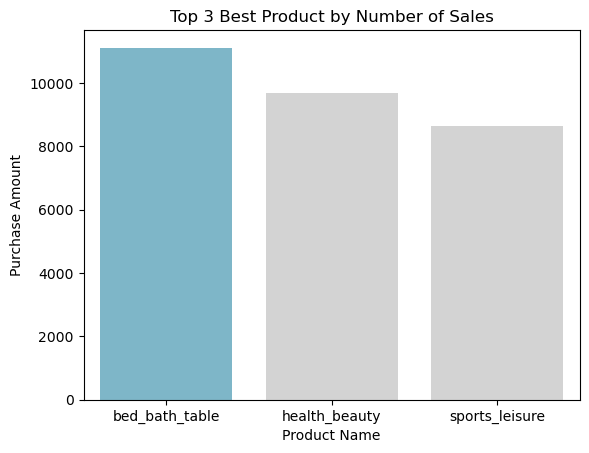

In [142]:
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    x='product_category_name_english', 
    y='order_item_id', 
    data=groupby_product.head(3), 
    palette=colors,
    hue='product_category_name_english',
    legend=False,
)
plt.xlabel('Product Name')
plt.ylabel('Purchase Amount')
plt.title('Top 3 Best Product by Number of Sales')
plt.show()

### Pertanyaan 2: Apa saja top 3 terbawah produk yang paling banyak dibeli ?

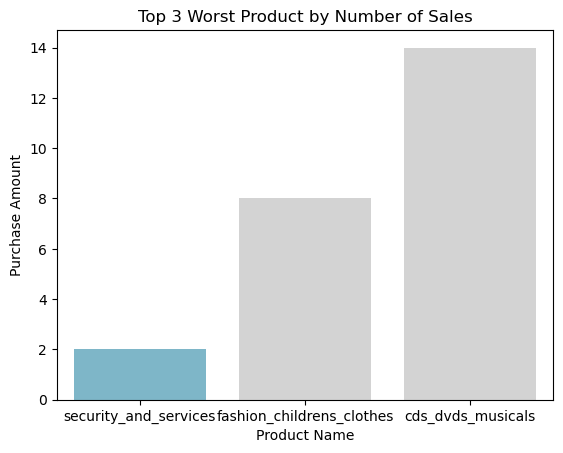

In [143]:
colors = ["#D3D3D3", "#D3D3D3", "#72BCD4"]
sns.barplot(
    x='product_category_name_english', 
    y='order_item_id', 
    data=groupby_product.tail(3), 
    palette=colors,
    hue='product_category_name_english',
    legend=False,
    order=['security_and_services', 'fashion_childrens_clothes', 'cds_dvds_musicals']
)
plt.xlabel('Product Name')
plt.ylabel('Purchase Amount')
plt.title('Top 3 Worst Product by Number of Sales')
plt.show()

### Pertanyaan 3: Payment_Type apa yang paling banyak digunakan untuk pembayaran dan berapa persentasenya ?

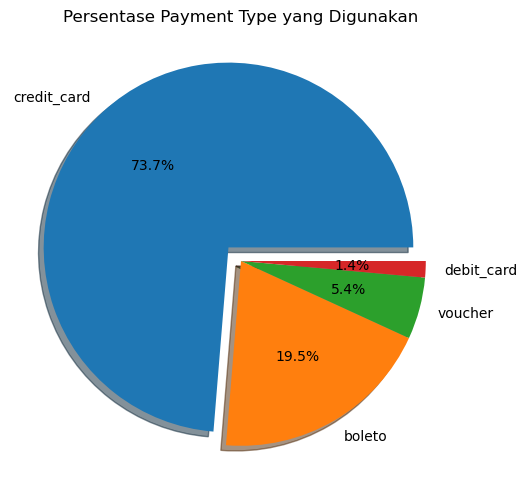

In [144]:
explode = (0.1, 0, 0, 0)
plt.figure(figsize=(6,6))
plt.title('Persentase Payment Type yang Digunakan')
plt.pie(
    groupby_payment_type['payment_installments'].head(4),
    explode=explode,
    labels=groupby_payment_type['payment_type'].head(4),
    autopct='%1.1f%%',
    shadow=True,
)

plt.show()

In [ ]:
# Export data
all_df.to_csv('./dashboard/main_data.csv', index=False)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan visualisasi yang telah ditampilkan dalam bentuk bar chart, terlihat jelas bahwa produk yang paling banyak dibeli adalah **bed_bath_table**
- **Conclusion pertanyaan 2:** Berdasarkan visualisasi yang telah ditampilkan dalam bentuk bar chart, terlihat jelas bahwa produk yang paling sedikit dibeli adalah **security_and_services**
- **Conclusion pertanyaan 3:** Berdasarkan visualisasi yang telah ditampilkan dalam bentuk bar chart dan pie chart, terlihat jelas bahwa payment_type yang paling banyak digunakan adalah **credit_card** dengan persentase 73.7%

**Rekomendasi Action Item:**
- Terdapat 3 produk yang paling banyak dibeli oleh customer dan juga 3 produk yang sedikit dibeli. Untuk produk yang banyak dibeli, bisa saja stok untuk 3 produk teratas itu, diperbanyak agar penjualan bisa meningkat. Dan untuk produk yang paling sedikit dibeli, sebaiknya stoknya dipertahankan atau dikurangi saja. Sebagai gantinya, uangnya dapat digunakan untuk menambah dana ketika membeli produk teratas tadi
- Berdasarkan visualisasi pie chart untuk payment type nya yang paling banyak digunakan ialah credit_card. Tidak ada rekomendasi khusus untuk hal ini, karena ini hanya memantau seberapa suka customer menggunakan fasilitas "Beli sekarang, bayar nanti"